Dane zaimportowane pomyślnie!

Podgląd struktury zbioru
<class 'pandas.DataFrame'>
RangeIndex: 1700 entries, 0 to 1699
Columns: 123 entries, AGE to LET_IS
dtypes: float64(110), int64(13)
memory usage: 1.6 MB
None

Brakujące wartości przed czyszczeniem (Top 5)
KFK_BLOOD     1696
IBS_NASL      1628
D_AD_KBRIG    1076
S_AD_KBRIG    1076
NOT_NA_KB      686
dtype: int64

Podstawowe statystyki opisowe
               AGE          SEX     INF_ANAM    STENOK_AN    FK_STENOK  \
count  1700.000000  1700.000000  1700.000000  1700.000000  1700.000000   
mean     61.862353     0.626471     0.553529     2.234118     1.239412   
std      11.233668     0.483883     0.836248     2.384571     1.030883   
min      26.000000     0.000000     0.000000     0.000000     0.000000   
25%      54.000000     0.000000     0.000000     0.000000     0.000000   
50%      63.000000     1.000000     0.000000     1.000000     2.000000   
75%      70.000000     1.000000     1.000000     5.000000     2.000000   
max      

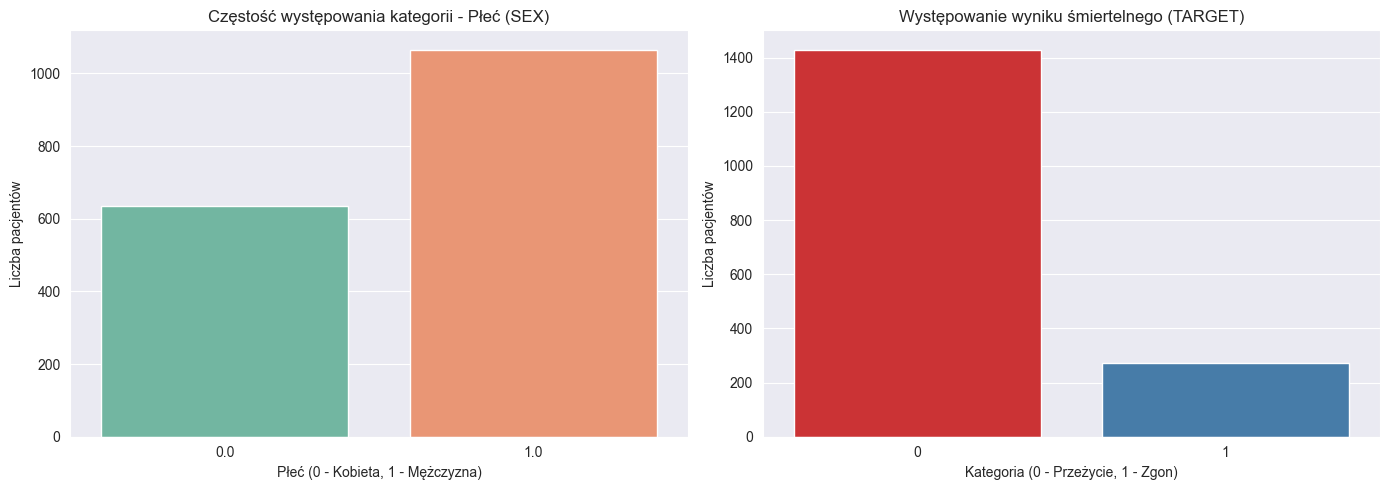

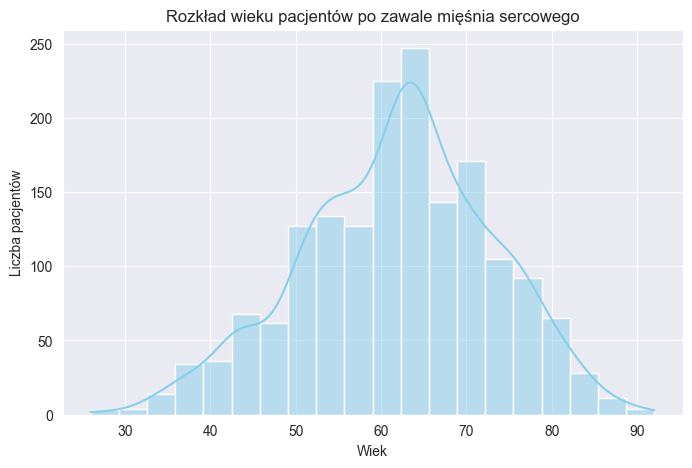

Wyniki modely predykcyjnego
Dokładność (Accuracy): 0.7835

Raport klasyfikacji:
              precision    recall  f1-score   support

           0       0.93      0.80      0.86       357
           1       0.40      0.69      0.51        68

    accuracy                           0.78       425
   macro avg       0.66      0.75      0.68       425
weighted avg       0.85      0.78      0.80       425



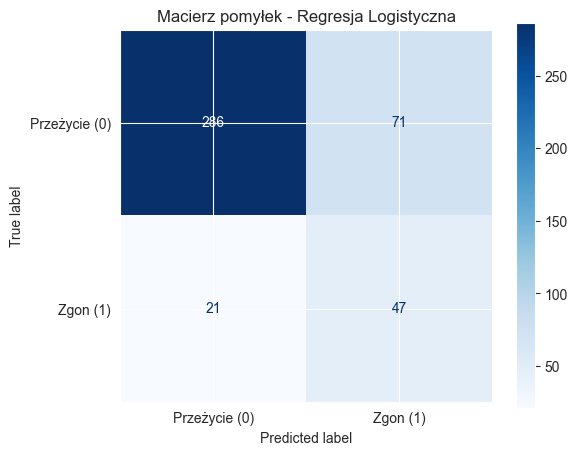

In [3]:
from PIL._imaging import display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings("ignore")

#Import danych

DATA_PATH = "complications.csv"
try:
    df = pd.read_csv(DATA_PATH)
    print("Dane zaimportowane pomyślnie!")
except FileNotFoundError:
    print(f"Nie znaleziono pliku {DATA_PATH}. Upewnij się, że jest w odpowiednim folderze.")


if 'ID' in df.columns:
    df = df.drop(columns=['ID'])

print("\nPodgląd struktury zbioru")
print(df.info())


#Wstępne przetwarzanie danych

print("\nBrakujące wartości przed czyszczeniem (Top 5)")
print(df.isnull().sum().sort_values(ascending=False).head())

imputer = SimpleImputer(strategy='median')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)


#Zmienna LET_IS (Lethal outcome) określa wynik śmiertelny i przyjmuje wartości od 0 do 7.
#Sprowadzamy to do problemu binarnego: 0 (przeżycie), 1 (zgon - jakakolwiek wartość > 0)
if 'LET_IS' in df_imputed.columns:
    df_imputed['TARGET'] = (df_imputed['LET_IS'] > 0).astype(int)
    df_imputed = df_imputed.drop(columns=['LET_IS'])


complications_cols =['FIBR_PREDS', 'PREDS_TAH', 'JELUD_TAH', 'FIBR_JELUD',
                      'A_V_BLOK', 'OTEK_LANC', 'RAZRIV', 'DRESSLER', 'ZSN', 'REC_IM', 'P_IM_STEN']
df_imputed = df_imputed.drop(columns=[c for c in complications_cols if c in df_imputed.columns])


#Analiza i wizualizacja

print("\nPodstawowe statystyki opisowe")
print(df_imputed.describe())

#Wizualizacja pokazująca częstość występowania różnych kategorii
plt.figure(figsize=(14, 5))

# Wykres 1: Częstość kategorii - Płeć pacjentów
plt.subplot(1, 2, 1)
if 'SEX' in df_imputed.columns:
    sns.countplot(data=df_imputed, x='SEX', palette='Set2')
    plt.title('Częstość występowania kategorii - Płeć (SEX)')
    plt.xlabel('Płeć (0 - Kobieta, 1 - Mężczyzna)')
    plt.ylabel('Liczba pacjentów')

# Wykres 2: Częstość występowania zmiennej docelowej (Wynik śmiertelny)
plt.subplot(1, 2, 2)
sns.countplot(data=df_imputed, x='TARGET', palette='Set1')
plt.title('Występowanie wyniku śmiertelnego (TARGET)')
plt.xlabel('Kategoria (0 - Przeżycie, 1 - Zgon)')
plt.ylabel('Liczba pacjentów')

plt.tight_layout()
plt.show()

# Dodatkowy histogram dla wieku (rozkład zmiennej ciągłej)
if 'AGE' in df_imputed.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(df_imputed['AGE'], bins=20, kde=True, color='skyblue')
    plt.title('Rozkład wieku pacjentów po zawale mięśnia sercowego')
    plt.xlabel('Wiek')
    plt.ylabel('Liczba pacjentów')
    plt.show()


#Przygotowanie do modelowania

#Podział na cechy (X) i etykiety (y)
X = df_imputed.drop(columns=['TARGET'])
y = df_imputed['TARGET']

#Podział na zbiór treningowy (75%) i testowy (25%) ze stratyfikacją
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

#Standaryzacja danych
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Zbudowanie prostego modelu predykcyjnego (Regresja Logistyczna)
model = LogisticRegression(max_iter=1000, class_weight='balanced') # class_weight pomaga na niezbalansowane klasy
model.fit(X_train_scaled, y_train)

#Wykonanie predykcji na zbiorze testowym
y_pred = model.predict(X_test_scaled)

#Ewaluacja modelu

print("Wyniki modely predykcyjnego")
print(f"Dokładność (Accuracy): {accuracy_score(y_test, y_pred):.4f}\n")
print("Raport klasyfikacji:")
print(classification_report(y_test, y_pred))

#Wizualizacja macierzy pomyłek
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Przeżycie (0)", "Zgon (1)"])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax, values_format="d")
plt.title('Macierz pomyłek - Regresja Logistyczna')
plt.show()